<a href="https://colab.research.google.com/github/Abirami-m123/HEIN./blob/master/Train_Mars_terrain_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("brsdincer/hirise-map-mars-nasa-image")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/hirise-map-mars-nasa-image


In [ ]:
import os

# List contents
print("Files in dataset:")
for file in os.listdir(path):
    print(file)


Files in dataset:
hirise-map-proj-v3
hirise-map-proj-v3_2


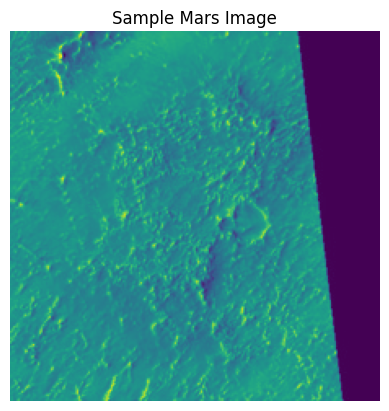

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Recursively find the first image file
def find_first_image_file(directory, exts=(".png", ".jpg", ".jpeg", ".tif", ".tiff")):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(exts):
                return os.path.join(root, file)
    return None

image_path = find_first_image_file(path)

if image_path:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title("Sample Mars Image")
    plt.axis("off")
    plt.show()
else:
    print("No image file found in dataset.")


Clustering Using Pretrained CNN

In [ ]:
pip install torchvision scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
pip install tqdm


In [ ]:

import os
from tqdm import tqdm
import pickle

def collect_image_paths(root):
    image_paths = []
    for r, _, files in tqdm(os.walk(root), desc="🗂️ Scanning folders"):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(r, file))
    return image_paths

dataset_root = "/kaggle/input/hirise-map-mars-nasa-image"
image_paths = collect_image_paths(dataset_root)
print("✅ Total images:", len(image_paths))

with open("image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)



🗂️ Scanning folders: 6it [01:41, 16.94s/it]

✅ Total images: 137978


In [ ]:
import os
import pickle
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

# === CONFIG ===
dataset_root = "/kaggle/input/hirise-map-mars-nasa-image"
batch_size = 5000
save_prefix = "features_batch_"

# === Collect all image paths ===
image_paths = []
for root, _, files in tqdm(os.walk(dataset_root), desc="🗂️ Scanning folders"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))
image_paths = image_paths[:70000]
print("✅ Total images selected for processing:", len(image_paths))

# === Model and transform ===
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# === Batch extraction with tqdm ===
for i in range(0, len(image_paths), batch_size):
    batch_paths = image_paths[i:i+batch_size]
    batch_features, batch_valid_paths = [], []

    print(f"\n⚙️ Batch {i // batch_size + 1}: {len(batch_paths)} images")

    for path in tqdm(batch_paths, desc=f"🔍 Extracting Batch {i}", leave=False):
        try:
            img = Image.open(path).convert("RGB")
            img_t = transform(img).unsqueeze(0)
            with torch.no_grad():
                feat = model(img_t).squeeze().numpy()
            batch_features.append(feat)
            batch_valid_paths.append(path)
        except Exception as e:
            continue

    if batch_features:
        with open(f"{save_prefix}{i}.pkl", "wb") as f:
            pickle.dump((batch_features, batch_valid_paths), f)
        print(f"✅ Saved: {save_prefix}{i}.pkl ({len(batch_features)} features)")
    else:
        print("⚠️ Skipped saving (empty batch)")


🗂️ Scanning folders: 6it [00:25,  4.29s/it]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


✅ Total images selected for processing: 70000


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]



⚙️ Batch 1: 5000 images


✅ Saved: features_batch_0.pkl (5000 features)

⚙️ Batch 2: 5000 images


...

✅ Saved: features_batch_45000.pkl (5000 features)

⚙️ Batch 11: 5000 images


✅ Saved: features_batch_50000.pkl (5000 features)

⚙️ Batch 12: 5000 images


✅ Saved: features_batch_55000.pkl (5000 features)

⚙️ Batch 13: 5000 images


✅ Saved: features_batch_60000.pkl (5000 features)

⚙️ Batch 14: 5000 images


✅ Saved: features_batch_65000.pkl (5000 features)


In [ ]:
import os
import pickle
import numpy as np
from tqdm import tqdm

# Adjust if needed
batch_prefix = "features_batch_"
num_batches = 14  # Since 70,000 / 5000 = 14

all_features = []
all_paths = []

for i in range(0, num_batches * 5000, 5000):
    batch_file = f"{batch_prefix}{i}.pkl"
    if os.path.exists(batch_file):
        with open(batch_file, "rb") as f:
            features, paths = pickle.load(f)
            all_features.extend(features)
            all_paths.extend(paths)
    else:
        print(f"⚠️ Missing: {batch_file}")

print(f"✅ Total features: {len(all_features)}")


✅ Total features: 70000


In [ ]:
from sklearn.cluster import KMeans

k = 6  # Based on your terrain label types: crater, dune, impact ejecta, slope streak, spider, etc.
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(all_features)

# Save clustered output
with open("clustered_labels.pkl", "wb") as f:
    pickle.dump((labels, all_paths), f)

print("✅ Saved clustered labels.")


✅ Saved clustered labels.


In [ ]:
import os
import pickle
import numpy as np
from tqdm import tqdm

# Load all batches
all_features = []
all_image_paths = []

for i in range(0, 70000, 5000):  # You saved 70K in 5K batches
    batch_file = f"features_batch_{i}.pkl"
    if os.path.exists(batch_file):
        with open(batch_file, "rb") as f:
            features, paths = pickle.load(f)
            all_features.extend(features)
            all_image_paths.extend(paths)

print(f"✅ Total loaded features: {len(all_features)}")


✅ Total loaded features: 70000


In [ ]:
from sklearn.cluster import KMeans

print("⚙️ Running KMeans on 70K features...")
k = 5  # number of terrain classes
kmeans = KMeans(n_clusters=k, random_state=42, verbose=1)
labels = kmeans.fit_predict(np.array(all_features))

print("✅ Clustering complete.")

⚙️ Running KMeans on 70K features...
Initialization complete
Iteration 0, inertia 6212480.0.
Iteration 1, inertia 4192795.0.
Iteration 2, inertia 4099768.5.
Iteration 3, inertia 4043667.25.
Iteration 4, inertia 4019604.0.
Iteration 5, inertia 4009631.25.
Iteration 6, inertia 4003226.0.
Iteration 7, inertia 3997607.75.
Iteration 8, inertia 3992702.0.
Iteration 9, inertia 3988278.5.
Iteration 10, inertia 3984550.25.
Iteration 11, inertia 3981629.75.
Iteration 12, inertia 3979739.75.
Iteration 13, inertia 3978529.0.
Iteration 14, inertia 3977618.0.
Iteration 15, inertia 3977009.75.
Iteration 16, inertia 3976566.0.
Iteration 17, inertia 3976191.25.
Iteration 18, inertia 3975915.5.
Iteration 19, inertia 3975699.25.
Iteration 20, inertia 3975517.25.
Iteration 21, inertia 3975406.0.
Iteration 22, inertia 3975274.5.
Iteration 23, inertia 3975136.75.
Iteration 24, inertia 3975081.75.
Iteration 25, inertia 3974991.0.
Iteration 26, inertia 3974916.5.
Iteration 27, inertia 3974890.0.
Iteration 28,

In [ ]:
with open("clustered_labels_70k.pkl", "wb") as f:
    pickle.dump((labels, all_image_paths), f)


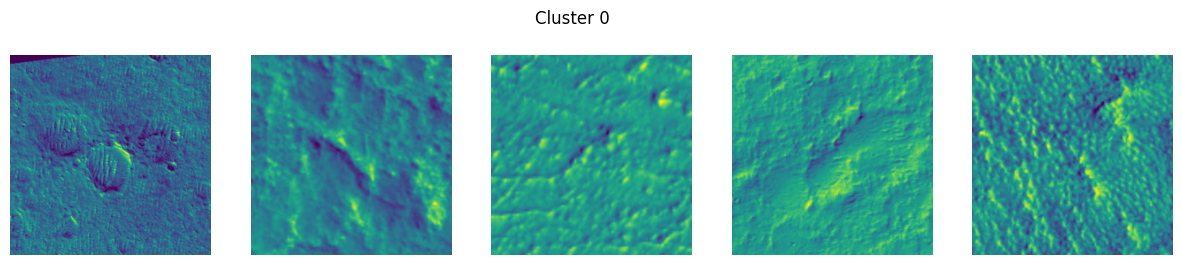

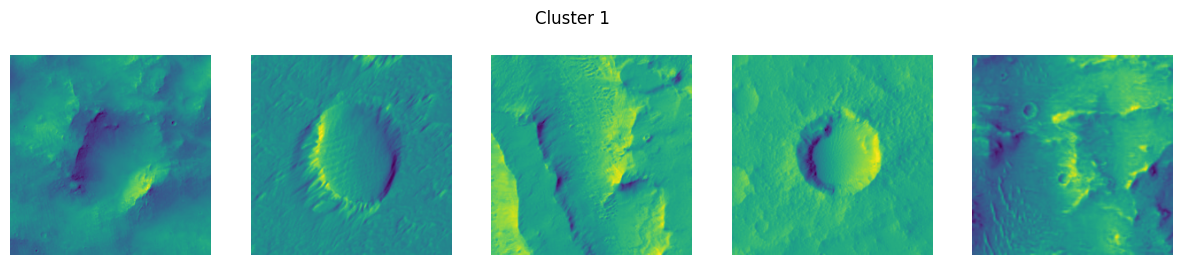

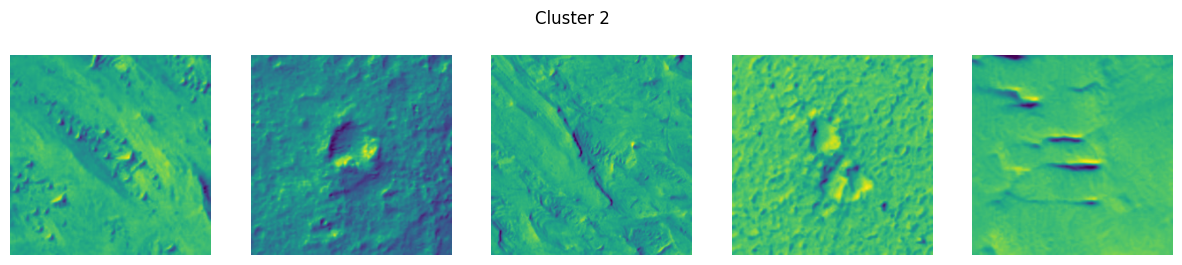

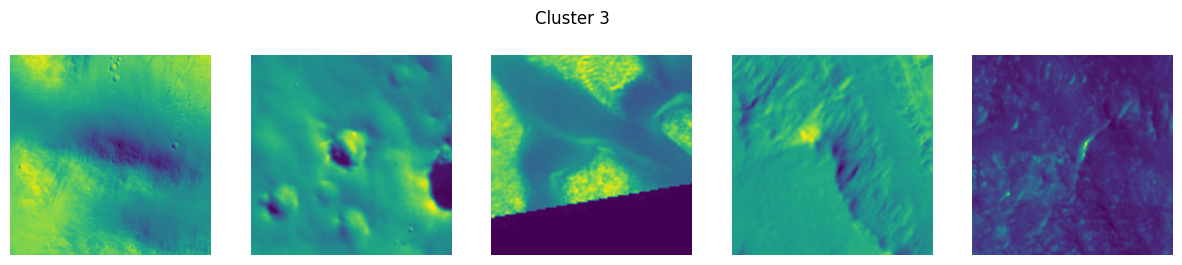

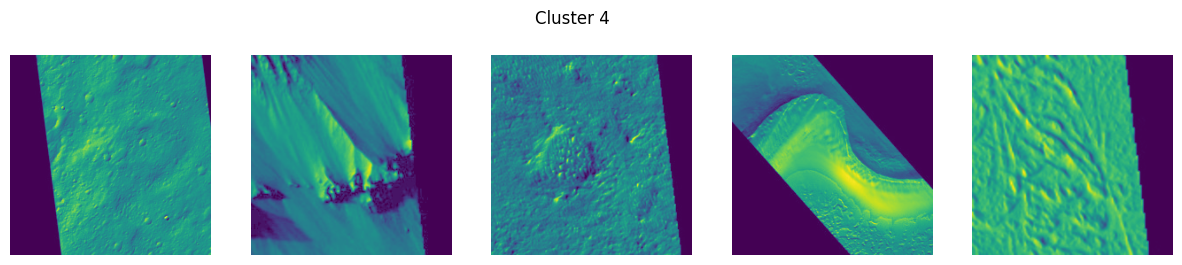

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_cluster_images(cluster_id, n=5):
    indices = [i for i, label in enumerate(labels) if label == cluster_id]
    sample = random.sample(indices, min(n, len(indices)))

    fig, axes = plt.subplots(1, len(sample), figsize=(15, 3))
    for ax, idx in zip(axes, sample):
        img = Image.open(all_image_paths[idx])
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle(f"Cluster {cluster_id}")
    plt.show()

# View a few clusters
for cluster_id in range(k):
    show_cluster_images(cluster_id)


In [ ]:
import pickle
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Load all extracted features from batches
all_features, all_paths = [], []

for i in range(0, 70000, 5000):  # adjust based on how many batches you've created
    with open(f"features_batch_{i}.pkl", "rb") as f:
        feats, paths = pickle.load(f)
        all_features.extend(feats)
        all_paths.extend(paths)

all_features = np.vstack(all_features)  # shape: [N, feature_dim]

# Step 2: Cluster features
k = 5  # 5 classes
kmeans = KMeans(n_clusters=k, random_state=42, verbose=1)
labels = kmeans.fit_predict(all_features)

# Step 3: Save labels + paths to .pkl
with open("clustered_labels_all.pkl", "wb") as f:
    pickle.dump((labels, all_paths), f)

print("✅ Clustered labels saved to clustered_labels_all.pkl")


Initialization complete
Iteration 0, inertia 6212480.0.
Iteration 1, inertia 4192795.0.
Iteration 2, inertia 4099768.5.
Iteration 3, inertia 4043667.25.
Iteration 4, inertia 4019604.0.
Iteration 5, inertia 4009631.25.
Iteration 6, inertia 4003226.0.
Iteration 7, inertia 3997607.75.
Iteration 8, inertia 3992702.0.
Iteration 9, inertia 3988278.5.
Iteration 10, inertia 3984550.25.
Iteration 11, inertia 3981629.75.
Iteration 12, inertia 3979739.75.
Iteration 13, inertia 3978529.0.
Iteration 14, inertia 3977618.0.
Iteration 15, inertia 3977009.75.
Iteration 16, inertia 3976566.0.
Iteration 17, inertia 3976191.25.
Iteration 18, inertia 3975915.5.
Iteration 19, inertia 3975699.25.
Iteration 20, inertia 3975517.25.
Iteration 21, inertia 3975406.0.
Iteration 22, inertia 3975274.5.
Iteration 23, inertia 3975136.75.
Iteration 24, inertia 3975081.75.
Iteration 25, inertia 3974991.0.
Iteration 26, inertia 3974916.5.
Iteration 27, inertia 3974890.0.
Iteration 28, inertia 3974842.75.
Iteration 29, in

In [ ]:
import os
import pickle
from PIL import Image
from tqdm import tqdm

# Load clustered labels and image paths (from saved .pkl)
with open("clustered_labels_all.pkl", "rb") as f:
    labels, image_paths = pickle.load(f)

# Define cluster ID to class label mapping
cluster_to_label = {
    0: "crater",
    1: "dune",
    2: "impact_ejecta",
    3: "slope_streak",
    4: "spider"
}

# Output directory
output_dir = "/content/drive/MyDrive/final_dataset"
os.makedirs(output_dir, exist_ok=True)

# Create subdirectories for classes
for label in set(cluster_to_label.values()):
    os.makedirs(os.path.join(output_dir, label), exist_ok=True)

# Save images with correct class folders and progress
success, fail = 0, 0
for i, (img_path, cluster_id) in enumerate(tqdm(zip(image_paths, labels), total=len(labels), desc="📦 Saving images")):
    try:
        label = cluster_to_label[int(cluster_id)]
        dest_path = os.path.join(output_dir, label, f"{label}_{i}.jpg")

        img = Image.open(img_path).convert("RGB")
        img.save(dest_path, "JPEG")
        success += 1
    except Exception as e:
        fail += 1
        if fail <= 5:
            print(f"❌ Failed: {img_path} — {e}")

print(f"\n✅ Saved: {success} images")
print(f"❌ Failed: {fail} images")

📦 Saving images: 100%|██████████| 70000/70000 [01:36<00:00, 728.41it/s]


✅ Saved: 70000 images
❌ Failed: 0 images


In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder("/content/drive/MyDrive/final_dataset", transform=transform)
class_names = dataset.classes
print("✅ Classes found:", class_names)

# Split 80/20 for train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

✅ Classes found: ['crater', 'dune', 'impact_ejecta', 'slope_streak', 'spider']


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, len(class_names))
model = model.to(device)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
from tqdm import tqdm

num_epochs = 8

for epoch in range(num_epochs):
    model.train()
    total, correct, running_loss = 0, 0, 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pth")


        progress.set_postfix(loss=running_loss/total, acc=correct/total)

Epoch 8/8: 100%|██████████| 875/875 [06:08<00:00,  2.38it/s, acc=0.976, loss=0.00109]


In [10]:
# ✅ Save the trained model
import torch
torch.save(model.state_dict(), "mars_terrain_model_final.pth")
print("✅ Model saved as mars_terrain_model_final.pth")


✅ Model saved as mars_terrain_model_final.pth


In [12]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [13]:
import torch
torch.save(model.state_dict(), "/content/drive/MyDrive/mars_terrain_model_final.pth")
print("✅ Model saved to Drive.")


✅ Model saved to Drive.


In [ ]:
from sklearn.metrics import classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

               precision    recall  f1-score   support

       crater       0.89      0.91      0.90      3810
         dune       0.87      0.80      0.84      3146
impact_ejecta       0.84      0.84      0.84      3063
 slope_streak       0.83      0.88      0.85      2364
       spider       0.94      0.92      0.93      1617

     accuracy                           0.87     14000
    macro avg       0.87      0.87      0.87     14000
 weighted avg       0.87      0.87      0.87     14000



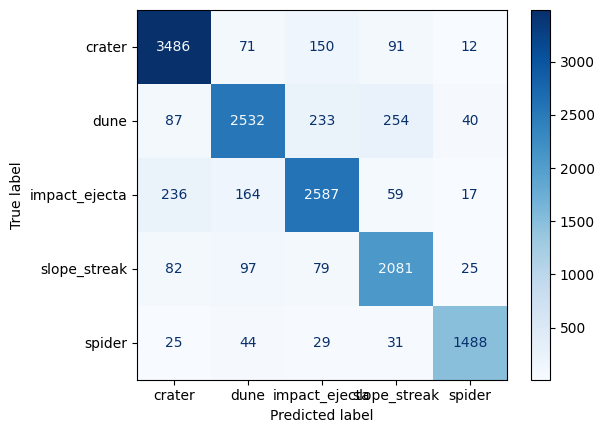

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, cmap="Blues")
plt.show()

In [33]:
import torch
import torchvision.models as models

# Define the model architecture
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 5)  # 5 classes

# Load weights
model.load_state_dict(torch.load("/content/drive/MyDrive/mars_terrain_model_final.pth"))
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class_names = ['crater', 'dune', 'impact_ejecta', 'slope_streak', 'spider']


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_and_visualize(image_path, model, transform, class_names):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        predicted_label = class_names[predicted.item()]

    # Visualize
    plt.imshow(image)
    plt.title(f"🔍 Predicted: {predicted_label}", fontsize=16)
    plt.axis("off")
    plt.show()


In [36]:
from google.colab import files

# Upload one or more images
uploaded = files.upload()


Saving ESP_011283_2265_RED-0017-brt.jpg to ESP_011283_2265_RED-0017-brt.jpg


In [37]:
import os

# Grab the first uploaded image
image_path = list(uploaded.keys())[0]
print("✅ Uploaded image path:", image_path)


✅ Uploaded image path: ESP_011283_2265_RED-0017-brt.jpg


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


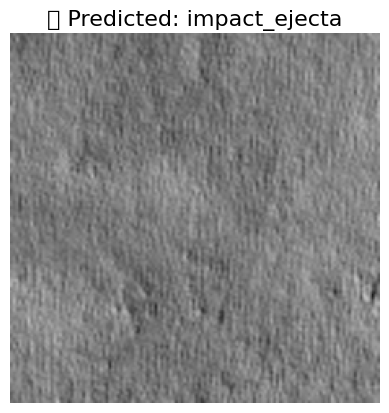

In [38]:
predict_and_visualize(image_path, model, transform, class_names)